In [43]:
import mrcfile
import torch
import matplotlib.pyplot as plt
import numpy as np

from torch_fourier_slice.slice_extraction._extract_central_slices_rfft_3d import (
    extract_central_slices_rfft_3d,
)
from pathlib import Path

In [87]:
def compare_slices(ground_truth_FS, angles, reconstructed_FSs: list, plots: bool = True):
    """
    Compare the slices of the ground truth FS with the reconstructed FSs.

    Parameters
    ----------
    ground_truth_FS : np.ndarray
        The ground truth FS.
    angles : list
        The angles of the slices.
    reconstructed_FSs : list
        A list of reconstructed FSs.
    plots : bool, optional
        Whether to plot the comparison of the slices.

    Returns
    -------
    If plots is True, it will plot the comparison of the slices.
        Plots the comparison of the slices.
    Elsewhise, it will return a score of differences between the ground truth FS and the reconstructed FSs.
    """

    return None

def compute_power_spectrum(data: np.ndarray) -> np.ndarray:
    ft = np.fft.fftshift(np.fft.fftn(data))
    return np.log(np.abs(ft) + 1e-8)  # small epsilon to avoid log(0)

def shape_into_cubic(volume):
    """
    Reshape a 3D volume into a cubic shape by removing values
    (center-crop each dimension down to the size of the smallest one).

    Parameters
    ----------
    volume : torch.Tensor
        The 3D volume to reshape.

    Returns
    -------
    torch.Tensor
        The reshaped cubic volume.
    """
    min_dim = min(volume.shape)
    slices = []
    for dim in volume.shape:
        start = dim // 2 - min_dim // 2
        end = start + min_dim
        slices.append(slice(start, end))
    return volume[tuple(slices)]

In [128]:
def plot_slice(data, axis=0, index=None, threshold=None, percentile=95):
    """
    Plot a 2D slice of a 3D field along the specified axis.
    If index is None, the middle slice is plotted.
    If threshold is None, it's set automatically using `percentile`
    (e.g. top 5% of intensity values).
    """
    if index is None:
        index = data.shape[axis] // 2

    if threshold is None:
        threshold = np.percentile(data, percentile)

    if axis == 0:
        slice_data = data[index, :, :]
    elif axis == 1:
        slice_data = data[:, index, :]
    elif axis == 2:
        slice_data = data[:, :, index]
    else:
        raise ValueError("Axis must be 0, 1, or 2.")

    plt.figure()
    plt.imshow(slice_data.T, origin='lower', cmap='gray', vmin=0, vmax=np.max(slice_data))
    plt.colorbar(label='Intensity')
    plt.title(f'Slice along axis {axis} at index {index} (threshold={threshold:.3f})')
    plt.xlabel('X-axis' if axis != 0 else 'Y-axis')
    plt.ylabel('Y-axis' if axis != 1 else 'Z-axis')
    plt.show()

def plot_image(data, title='Image', cmap='gray', vmin=None, vmax=None):
    plt.figure()
    plt.imshow(data, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(label='Intensity')
    plt.title(title)
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()


In [89]:
### Import the mrc files

base_path = Path("C:/Users/ruben/OneDrive - Delft University of Technology/Documenten/Nanobiology 6/ARP/tomo108/")

ground_truth = base_path / "tomo200528_108_10.00Apx.mrc"
icecream_truth = base_path / "tomo200528_108_10.00Apx_tomo200528_108_10.00Apx_icecream.mrc"
ddw_truth = base_path / "tomo200528_108_10.00Apx+tomo200528_108_10.00Apx_ddw_refined.mrc"

angles = [51.0, 48.0, -47.99, -50.99]

with mrcfile.open(ground_truth) as mrc:
    ground_truth_data = torch.tensor(mrc.data, dtype=torch.float32)
    ground_truth_data_PS = compute_power_spectrum(ground_truth_data.numpy())
    box_ground_truth_data = shape_into_cubic(ground_truth_data)
    box_ground_truth_data_PS = compute_power_spectrum(box_ground_truth_data.numpy())

with mrcfile.open(icecream_truth) as mrc:
    icecream_truth_data = torch.tensor(mrc.data, dtype=torch.float32)
    icecream_truth_data_PS = compute_power_spectrum(icecream_truth_data.numpy())
    box_icecream_truth_data = shape_into_cubic(icecream_truth_data)
    box_icecream_truth_data_PS = compute_power_spectrum(box_icecream_truth_data)

with mrcfile.open(ddw_truth) as mrc:
    ddw_truth_data = torch.tensor(mrc.data, dtype=torch.float32)
    ddw_truth_data_PS = compute_power_spectrum(ddw_truth_data.numpy())
    box_ddw_truth_data = shape_into_cubic(ddw_truth_data)
    box_ddw_truth_data_PS = compute_power_spectrum(box_ddw_truth_data.numpy())

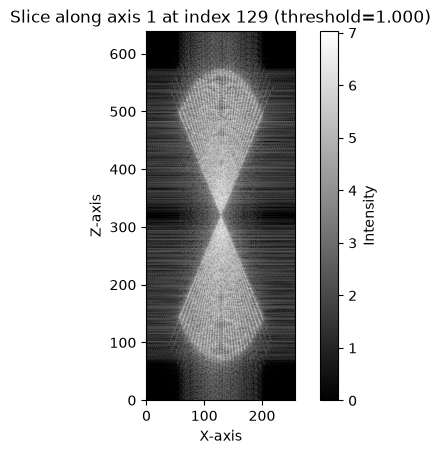

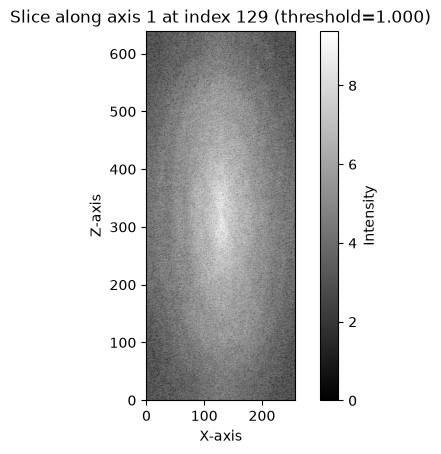

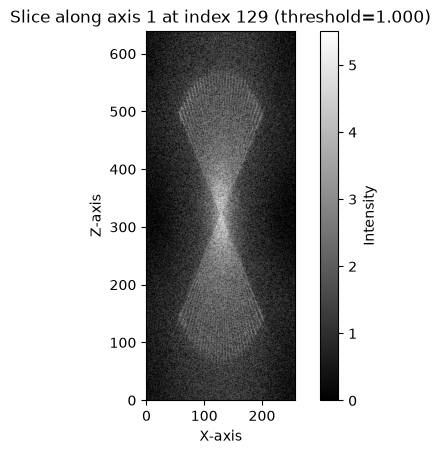

In [90]:
plot_slice(ground_truth_data_PS, axis=1, index=ground_truth_data.shape[0]//2, threshold=1, percentile=95)
plot_slice(icecream_truth_data_PS, axis=1, index=icecream_truth_data.shape[0]//2, threshold=1, percentile=95)
plot_slice(ddw_truth_data_PS, axis=1, index=ddw_truth_data.shape[0]//2, threshold=1, percentile=95)


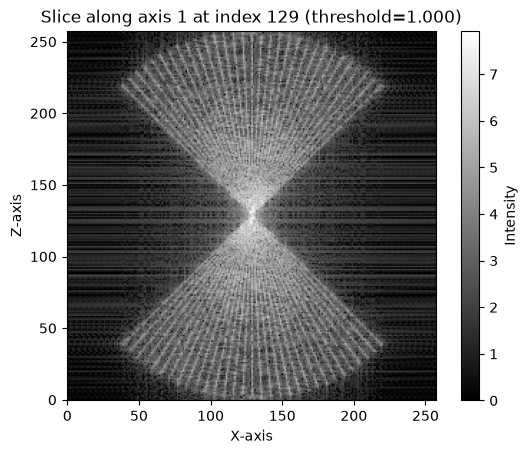

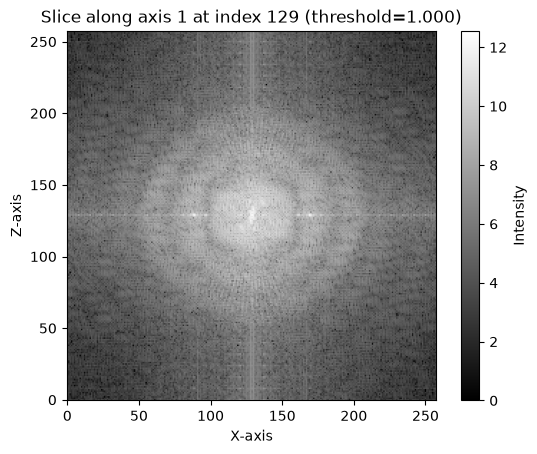

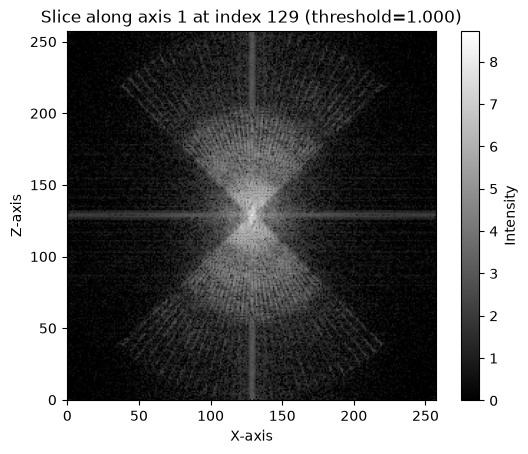

In [100]:
plot_slice(box_ground_truth_data_PS, axis=1, index=ground_truth_data.shape[0]//2, threshold=1, percentile=95)
plot_slice(box_icecream_truth_data_PS, axis=1, index=icecream_truth_data.shape[0]//2, threshold=1, percentile=95)
plot_slice(box_ddw_truth_data_PS, axis=1, index=ddw_truth_data.shape[0]//2, threshold=1, percentile=95)


In [116]:
def rotation_matrix_y(angle_deg, device="cpu"):
    theta = torch.deg2rad(torch.tensor(float(angle_deg), device=device))
    c, s = torch.cos(theta), torch.sin(theta)
    return torch.stack([
        torch.stack([ c, torch.tensor(0.0, device=device),  s]),
        torch.stack([ torch.tensor(0.0, device=device), torch.tensor(1.0, device=device), torch.tensor(0.0, device=device)]),
        torch.stack([-s, torch.tensor(0.0, device=device),  c]),
    ])

def extract_slices(volume, angles):
    """
    Extract slices from a 3D volume at specified angles.

    Parameters
    ----------
    volume : torch.Tensor
        The 3D volume from which to extract slices.
    angles : list
        A list of angles (in degrees) at which to extract slices.

    Returns
    -------
    torch.Tensor
        A tensor containing the extracted slices.
    """

    rotation_matrices = torch.stack([rotation_matrix_y(a) for a in angles])

    return extract_central_slices_rfft_3d(volume, rotation_matrices)

In [117]:
print(torch.fft.fftshift(torch.fft.fftn(box_ground_truth_data)).shape)

torch.Size([258, 258, 258])


In [123]:
images_ground_truth = extract_slices(torch.fft.fftshift(torch.fft.fftn(box_ground_truth_data)), angles)
images_icecream = extract_slices(torch.fft.fftshift(torch.fft.fftn(box_icecream_truth_data)), angles)
images_ddw = extract_slices(torch.fft.fftshift(torch.fft.fftn(box_ddw_truth_data)), angles)

In [142]:

for i, image in enumerate(images_ddw):
    data = np.abs(image.numpy())
    norm_data = data/np.max(data)
    # clip_data = np.clip(norm_data, threshold, 1)
    # plot_image(norm_data, title=f'Ground Truth Slice at {angles[i]} degrees', cmap='gray')

    #plot fourier (real space) of the slice
    # real_space = np.fft.ifft(image.numpy())
    # plot_image(real_space.real, title=f'Ground Truth Real Space Slice at {angles[i]} degrees', cmap='gray')

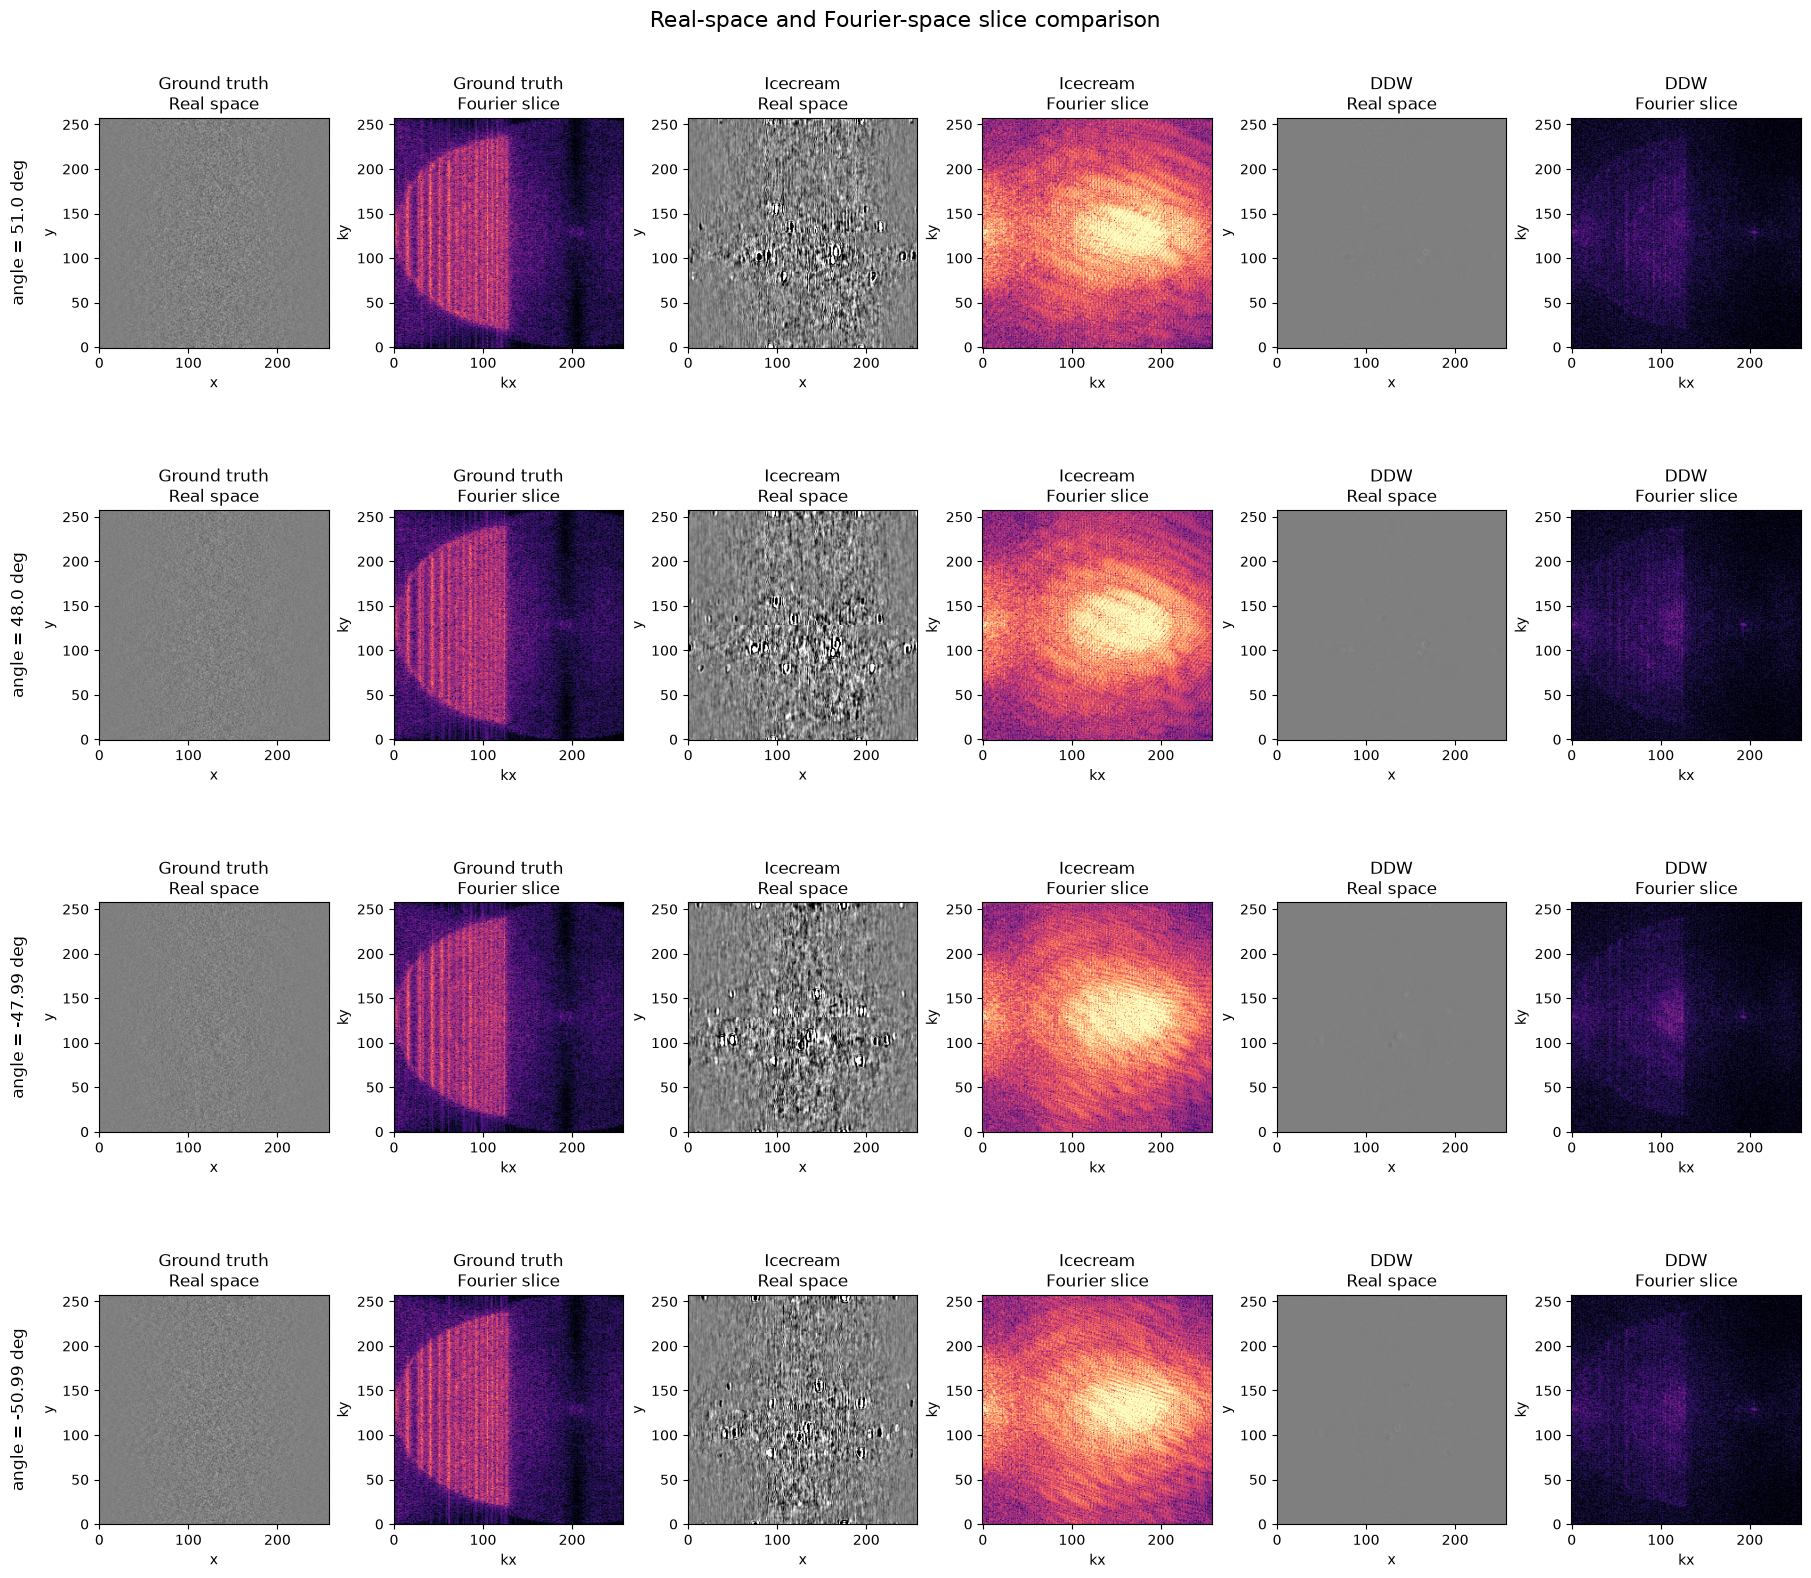

In [141]:
def fourier_slice_to_real_space(fourier_slice):
    """Convert a centered 2D Fourier slice into a centered real-space projection."""
    fourier_slice = np.asarray(fourier_slice)
    return np.fft.fftshift(
        np.fft.ifft2(np.fft.ifftshift(fourier_slice)).real
    )


volume_names = ["Ground truth", "Icecream", "DDW"]
volume_slices = [images_ground_truth, images_icecream, images_ddw]

fig, axes = plt.subplots(
    nrows=len(angles),
    ncols=2 * len(volume_slices),
    figsize=(18, 4 * len(angles)),
    constrained_layout=True,
)

for angle_index, angle in enumerate(angles):
    real_space_slices = [
        fourier_slice_to_real_space(volume[angle_index].detach().cpu().numpy())
        for volume in volume_slices
    ]
    fourier_space_slices = [
        np.log1p(np.abs(volume[angle_index].detach().cpu().numpy()))
        for volume in volume_slices
    ]

    real_values = np.concatenate([slice_data.ravel() for slice_data in real_space_slices])
    real_limit = np.percentile(np.abs(real_values), 99)
    fourier_values = np.concatenate([slice_data.ravel() for slice_data in fourier_space_slices])
    fourier_limits = (np.percentile(fourier_values, 1), np.percentile(fourier_values, 99))

    for volume_index, volume_name in enumerate(volume_names):
        real_axis = axes[angle_index, 2 * volume_index]
        fourier_axis = axes[angle_index, 2 * volume_index + 1]

        real_axis.imshow(
            real_space_slices[volume_index],
            cmap="gray",
            origin="lower",
            vmin=-real_limit,
            vmax=real_limit,
        )
        real_axis.set_title(f"{volume_name}\nReal space")
        real_axis.set_xlabel("x")
        real_axis.set_ylabel("y")

        fourier_axis.imshow(
            fourier_space_slices[volume_index],
            cmap="magma",
            origin="lower",
            vmin=fourier_limits[0],
            vmax=fourier_limits[1],
        )
        fourier_axis.set_title(f"{volume_name}\nFourier slice")
        fourier_axis.set_xlabel("kx")
        fourier_axis.set_ylabel("ky")

    axes[angle_index, 0].annotate(
        f"angle = {angle} deg",
        xy=(-0.35, 0.5),
        xycoords="axes fraction",
        rotation=90,
        va="center",
        ha="center",
        fontsize=12,
    )

fig.suptitle("Real-space and Fourier-space slice comparison", fontsize=16)
plt.show()
